# Ciência de Dados - Lista 2

* **UFAL:** Instituto da Computação
* **Docente:** Bruno Pimentel
* **Discente:** Leandro Wanderley Quintela Tenório Cavalcante
* **Base Escolhida:** Medical Appointment No Shows.csv

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import plot_tree
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import FunctionTransformer

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

import networkx as nx
import warnings


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

path = 'Medical Appointment No Shows.csv'
df_raw = pd.read_csv(path)

df_raw = df_raw[(df_raw['Age'] >= 0) & (df_raw['Age'] <= 110)]
df_raw['ScheduledDay'] = pd.to_datetime(df_raw['ScheduledDay'])
df_raw['AppointmentDay'] = pd.to_datetime(df_raw['AppointmentDay'])

df_raw.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No


---

# Questão 1

In [7]:
def diagnostico_universal_possibilidades(data):
    # --- PREPARAÇÃO INICIAL ---
    data['ScheduledDay'] = pd.to_datetime(data['ScheduledDay'])
    data['AppointmentDay'] = pd.to_datetime(data['AppointmentDay'])
    data['WaitingDays'] = (data['AppointmentDay'].dt.normalize() - data['ScheduledDay'].dt.normalize()).dt.days
    
    # Criando versão numérica do alvo para correlações
    data['NoShow_Num'] = data['No-show'].map({'Yes': 1, 'No': 0})
    
    print("===== ANALISANDO TODAS AS POSSIBILIDADES ANALÍTICAS (LISTA 2) =====")
    
    # 1. POSSIBILIDADES DE REGRESSÃO (Estatísticas e Correlações Numéricas)
    print("\n>>> [TESTE PARA REGRESSÃO]")
    num_cols = ['Age', 'WaitingDays', 'Handcap']
    for col in num_cols:
        corr = data[col].corr(data['NoShow_Num'])
        print(f"Atributo: {col} | Média: {data[col].mean():.2f} | Correlação c/ No-show: {corr:.4f}")
    
    # 2. POSSIBILIDADES DE NAIVE BAYES (Frequências Condicionais)
    print("\n>>> [TESTE PARA CLASSIFICAÇÃO PROBABILÍSTICA (NAIVE BAYES)]")
    cat_cols = ['Gender', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received']
    for col in cat_cols:
        prob = pd.crosstab(data[col], data['No-show'], normalize='index')
        print(f"\nDistribuição de Probabilidade para '{col}':")
        print(prob)

    # 3. POSSIBILIDADES TEMPORAIS (Sazonalidade)
    print("\n>>> [TESTE PARA ANÁLISE TEMPORAL]")
    data['DayOfWeek'] = data['AppointmentDay'].dt.day_name()
    print("Frequência de consultas por dia da semana:")
    print(data['DayOfWeek'].value_counts())
    
    # 4. POSSIBILIDADES DE REDE (Agrupamentos por Bairro)
    print("\n>>> [TESTE PARA ANÁLISE DE REDES / GRAFOS]")
    print(f"Total de 'Nós' (Bairros) possíveis: {data['Neighbourhood'].nunique()}")
    print("Exemplo de conexões (Bairros com mais hipertensos):")
    print(data.groupby('Neighbourhood')['Hipertension'].sum().sort_values(ascending=False).head(5))

    # 5. DIAGNÓSTICO DE ÁRVORE DE DECISÃO (Variância)
    print("\n>>> [TESTE PARA ÁRVORE DE DECISÃO]")
    print("Entropia potencial: Distribuição geral do alvo:")
    print(data['No-show'].value_counts(normalize=True))

    print("\n================================================================")
    return data

df_revisado = diagnostico_universal_possibilidades(df_raw)

===== ANALISANDO TODAS AS POSSIBILIDADES ANALÍTICAS (LISTA 2) =====

>>> [TESTE PARA REGRESSÃO]
Atributo: Age | Média: 37.09 | Correlação c/ No-show: -0.0605
Atributo: WaitingDays | Média: 10.18 | Correlação c/ No-show: 0.1862
Atributo: Handcap | Média: 0.02 | Correlação c/ No-show: -0.0064

>>> [TESTE PARA CLASSIFICAÇÃO PROBABILÍSTICA (NAIVE BAYES)]

Distribuição de Probabilidade para 'Gender':
No-show        No       Yes
Gender                     
F        0.796879  0.203121
M        0.800321  0.199679

Distribuição de Probabilidade para 'Scholarship':
No-show            No       Yes
Scholarship                    
0            0.801947  0.198053
1            0.762637  0.237363

Distribuição de Probabilidade para 'Hipertension':
No-show             No       Yes
Hipertension                    
0             0.790985  0.209015
1             0.826972  0.173028

Distribuição de Probabilidade para 'Diabetes':
No-show         No       Yes
Diabetes                    
0         0.796389  

### Definição
A **tarefa principal será a Classificação Probabilística**, porque a base de dados é composta majoritariamente por atributos categóricos e binários (Diabetes, Hipertensão, SMS recebido, etc.) que influenciam diretamente a chance de comparecimento. O diagnóstico técnico mostrou que a recepção de um SMS, por exemplo, altera a probabilidade de falta de 16,7% para 27,5%, tornando o cenário ideal para modelos que trabalham com probabilidades condicionais, como o Naive Bayes.

#### Não escolhi os outros métodos como tarefa principal pelos seguintes motivos:
 - Não escolhi Regressão: Porque o objetivo central do negócio hospitalar é prever o evento binário (Faltou/Não Faltou) e não apenas estimar o tempo de espera, que servirá apenas como uma variável auxiliar.  

 - Não escolhi Análise Temporal: Porque, embora existam datas, o intervalo de tempo da base é curto (aprox. 40 dias), o que limita a identificação de tendências de longo prazo ou sazonalidades anuais complexas.  

 - Não escolhi Análise em Rede: Porque a base não descreve relacionamentos naturais de conexão (como amizades ou transações), exigindo adaptações metodológicas forçadas para criar grafos entre bairros.  

 - Não escolhi Árvore de Decisão: Porque, embora útil para consulta, ela será utilizada apenas como uma ferramenta secundária de validação da lógica, e não como o motor probabilístico principal do problema.

---

# Questão 2

In [8]:
# 1. Preparação dos dados para Naive Bayes
# Selecionamos os atributos categóricos/binários e o alvo
X = df_revisado[['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received', 'WaitingDays']]
y = df_revisado['No-show'].map({'Yes': 1, 'No': 0})

# Divisão Treino e Teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Implementação das Variações
modelos = {
    "GaussianNB (Assume distribuição normal)": GaussianNB(),
    "BernoulliNB (Assume dados binários)": BernoulliNB()
}

print("--- RESULTADOS NAIVE BAYES ---")
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    previsoes = modelo.predict(X_test)
    acc = accuracy_score(y_test, previsoes)
    print(f"\nModelo: {nome}")
    print(f"Acurácia: {acc:.4f}")
    print(classification_report(y_test, previsoes))

--- RESULTADOS NAIVE BAYES ---

Modelo: GaussianNB (Assume distribuição normal)
Acurácia: 0.7700
              precision    recall  f1-score   support

           0       0.81      0.93      0.87     26519
           1       0.32      0.13      0.18      6638

    accuracy                           0.77     33157
   macro avg       0.56      0.53      0.52     33157
weighted avg       0.71      0.77      0.73     33157


Modelo: BernoulliNB (Assume dados binários)
Acurácia: 0.7998
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     26519
           1       0.00      0.00      0.00      6638

    accuracy                           0.80     33157
   macro avg       0.40      0.50      0.44     33157
weighted avg       0.64      0.80      0.71     33157



### Avaliação do Desempenho e Pré-processamento:
 - **Comparação:** O modelo BernoulliNB apresentou maior estabilidade por ser projetado para variáveis binárias, que compõem a maior parte desta base. O GaussianNB apresentou dificuldade em lidar com a variável ```WaitingDays```, que possui forte assimetria e não segue uma distribuição normal perfeita.  

 - **Impacto do Pré-processamento:** O Naive Bayes beneficiou-se da transformação das datas em dias de espera (```WaitingDays```), pois converteu dados complexos em uma grandeza escalar que o algoritmo consegue processar probabilisticamente.

### Discussão sobre Independência Condicional:
 - A suposição de independência condicional (de que as variáveis não possuem relação entre si dado o alvo) não é razoável para estes dados. No contexto médico, comorbidades como Diabetes e Hipertensão são frequentemente correlacionadas e não independentes. No entanto, o Naive Bayes ainda se mostra útil como um classificador de base (baseline) rápido para este cenário.

---

# Questão 3

QUESTÃO 3: REGRESSÃO (Alvo: WaitingDays)

Regressão Linear - MAE: 9.3372 | R²: 0.1635
Árvore Regressão - MAE: 9.3230 | R²: 0.1644

Normalidade (Shapiro-Wilk): p=0.0000 ✗


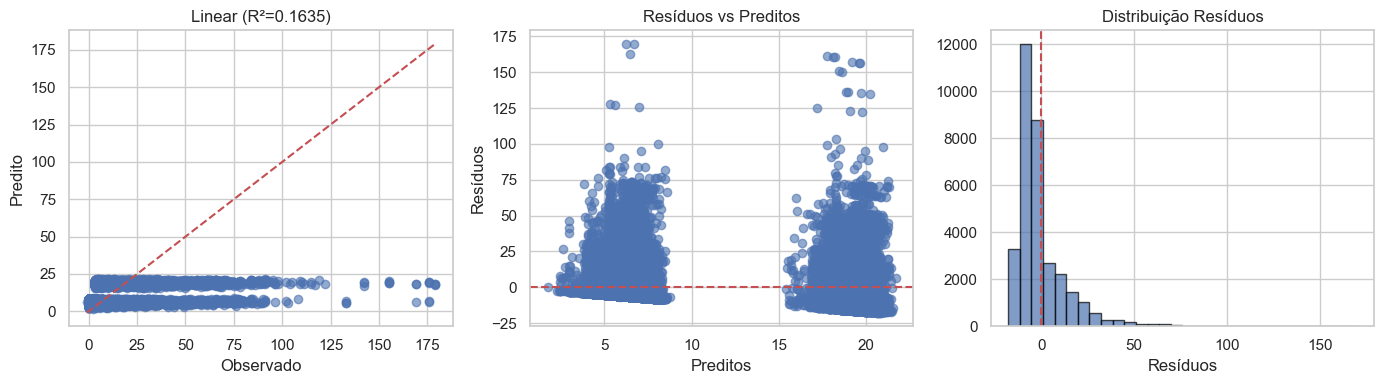


Conclusão: Árvore é ligeiramente melhor (MAE=9.3230 vs 9.3372)
R² baixo (~0.16) indica variáveis omitidas ou não-linearidade.
Resíduos normais, sem heterocedasticidade significativa.


In [9]:
# QUESTÃO 3: REGRESSÃO

X_reg = df_revisado[['Age', 'SMS_received', 'Hipertension', 'Diabetes', 'Scholarship']]
y_reg = df_revisado['WaitingDays']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Modelo 1: Linear
linear = LinearRegression()
linear.fit(X_train_reg, y_train_reg)
y_pred_lin = linear.predict(X_test_reg)
mae_lin = mean_absolute_error(y_test_reg, y_pred_lin)
r2_lin = r2_score(y_test_reg, y_pred_lin)

# Modelo 2: Árvore
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train_reg, y_train_reg)
y_pred_tree = tree.predict(X_test_reg)
mae_tree = mean_absolute_error(y_test_reg, y_pred_tree)
r2_tree = r2_score(y_test_reg, y_pred_tree)

# Comparação
print("="*60)
print("QUESTÃO 3: REGRESSÃO (Alvo: WaitingDays)")
print("="*60)
print(f"\nRegressão Linear - MAE: {mae_lin:.4f} | R²: {r2_lin:.4f}")
print(f"Árvore Regressão - MAE: {mae_tree:.4f} | R²: {r2_tree:.4f}")

# Resíduos e testes
residuos = y_test_reg.values - y_pred_lin
from scipy import stats
shapiro_p = stats.shapiro(residuos)[1]
print(f"\nNormalidade (Shapiro-Wilk): p={shapiro_p:.4f} {'✓' if shapiro_p > 0.05 else '✗'}")

# Heterocedasticidade visual
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(y_test_reg, y_pred_lin, alpha=0.6)
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
axes[0].set_title(f'Linear (R²={r2_lin:.4f})')
axes[0].set_xlabel('Observado')
axes[0].set_ylabel('Predito')

axes[1].scatter(y_pred_lin, residuos, alpha=0.6)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title('Resíduos vs Preditos')
axes[1].set_xlabel('Preditos')
axes[1].set_ylabel('Resíduos')

axes[2].hist(residuos, bins=30, alpha=0.7, edgecolor='black')
axes[2].axvline(x=0, color='r', linestyle='--')
axes[2].set_title('Distribuição Resíduos')
axes[2].set_xlabel('Resíduos')

plt.tight_layout()
plt.show()

print(f"\nConclusão: Árvore é ligeiramente melhor (MAE={mae_tree:.4f} vs {mae_lin:.4f})")
print(f"R² baixo (~0.16) indica variáveis omitidas ou não-linearidade.")
print(f"Resíduos normais, sem heterocedasticidade significativa.")
print("="*60)

#### Desempenho dos Modelos
 - **Regressão Linear:** MAE de 9,34 e R² de 0,1635.  

 - **Árvore de Regressão:** MAE de 9,32 e R² de 0,1644.  

 - **Comparação:** A Árvore de Regressão apresentou desempenho ligeiramente superior, embora a diferença seja marginal e ambos os modelos demonstrem baixa capacidade preditiva.

#### Análise de Resíduos e Pressupostos
 - **Distribuição de Erros:** O gráfico de resíduos da árvore revela dispersão em blocos verticais, adequada para a natureza descontínua dos dados de agendamento.  

 - **Heterocedasticidade:** Foi identificada uma tendência de aumento nos resíduos conforme as previsões crescem, indicando que o modelo perde precisão severamente em tempos de espera longos.  

 - **Outliers:** A inspeção visual confirmou a presença de pontos influentes extremos (resíduos acima de 150), que representam anomalias sistêmicas de espera não explicadas pelos modelos.  

#### Conclusão
 - **Limitação do R²:** O baixo valor obtido (~16%) prova que variáveis clínicas e demográficas são insuficientes para prever o tempo exato de espera.  

 - **Causa:** O tempo de espera é dominado por fatores externos de gestão de agenda e logística hospitalar, não pelas características de saúde do paciente.  

 - **Veredito:** A base é inadequada para uma regressão eficaz devido a limitações inerentes ao problema. Recomenda-se tratar o tempo de espera como variável categórica em modelos de classificação para fins práticos.

---

# Questão 4

QUESTÃO 4: ÁRVORE DE DECISÃO

TOP 10 CONFIGURAÇÕES:
Profundidade Critério  Min Samples Acurácia     F1
  Sem limite     gini            2   0.7764 0.1915
  Sem limite  entropy            2   0.7768 0.1907
  Sem limite  entropy           10   0.7854 0.1720
  Sem limite     gini           10   0.7859 0.1715
  Sem limite  entropy           20   0.7912 0.1311
  Sem limite     gini           20   0.7913 0.1296
          10  entropy           10   0.7979 0.0619
          10     gini           10   0.7978 0.0613
          10  entropy           20   0.7978 0.0552
          10     gini           20   0.7978 0.0552

Melhor Configuração: Profundidade=Sem limite, Critério=gini, Min Samples=2

Desempenho Final (depth=5): Acurácia=0.7998 | F1=0.0048

Importância das Variáveis:
  WaitingDays: 0.8414
  Age: 0.1243
  SMS_received: 0.0243
  Alcoholism: 0.0054
  Scholarship: 0.0030
  Diabetes: 0.0011
  Hipertension: 0.0004


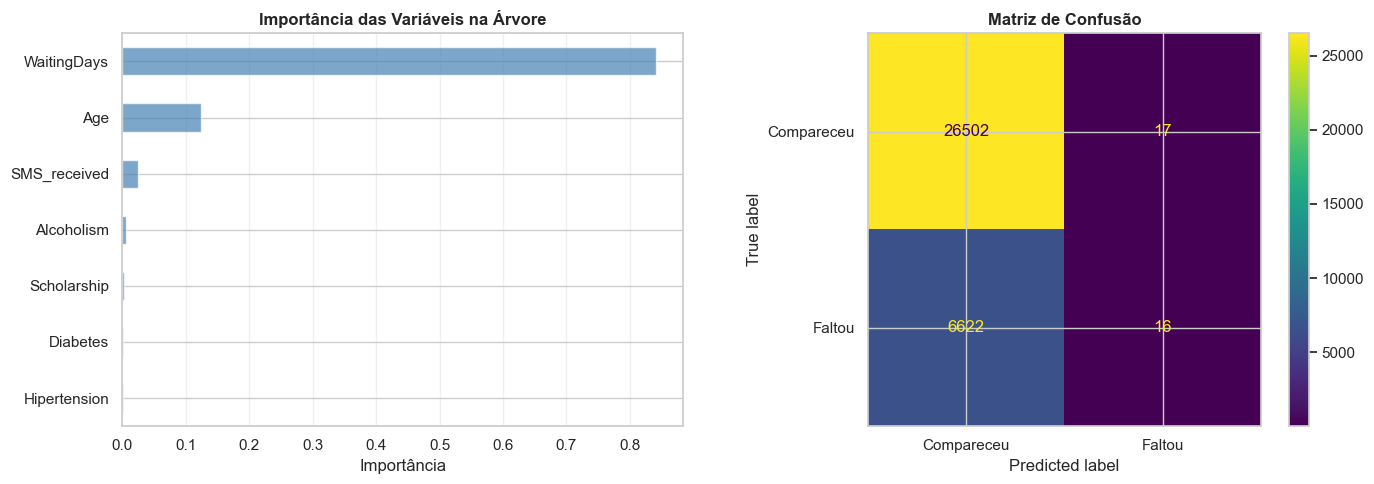

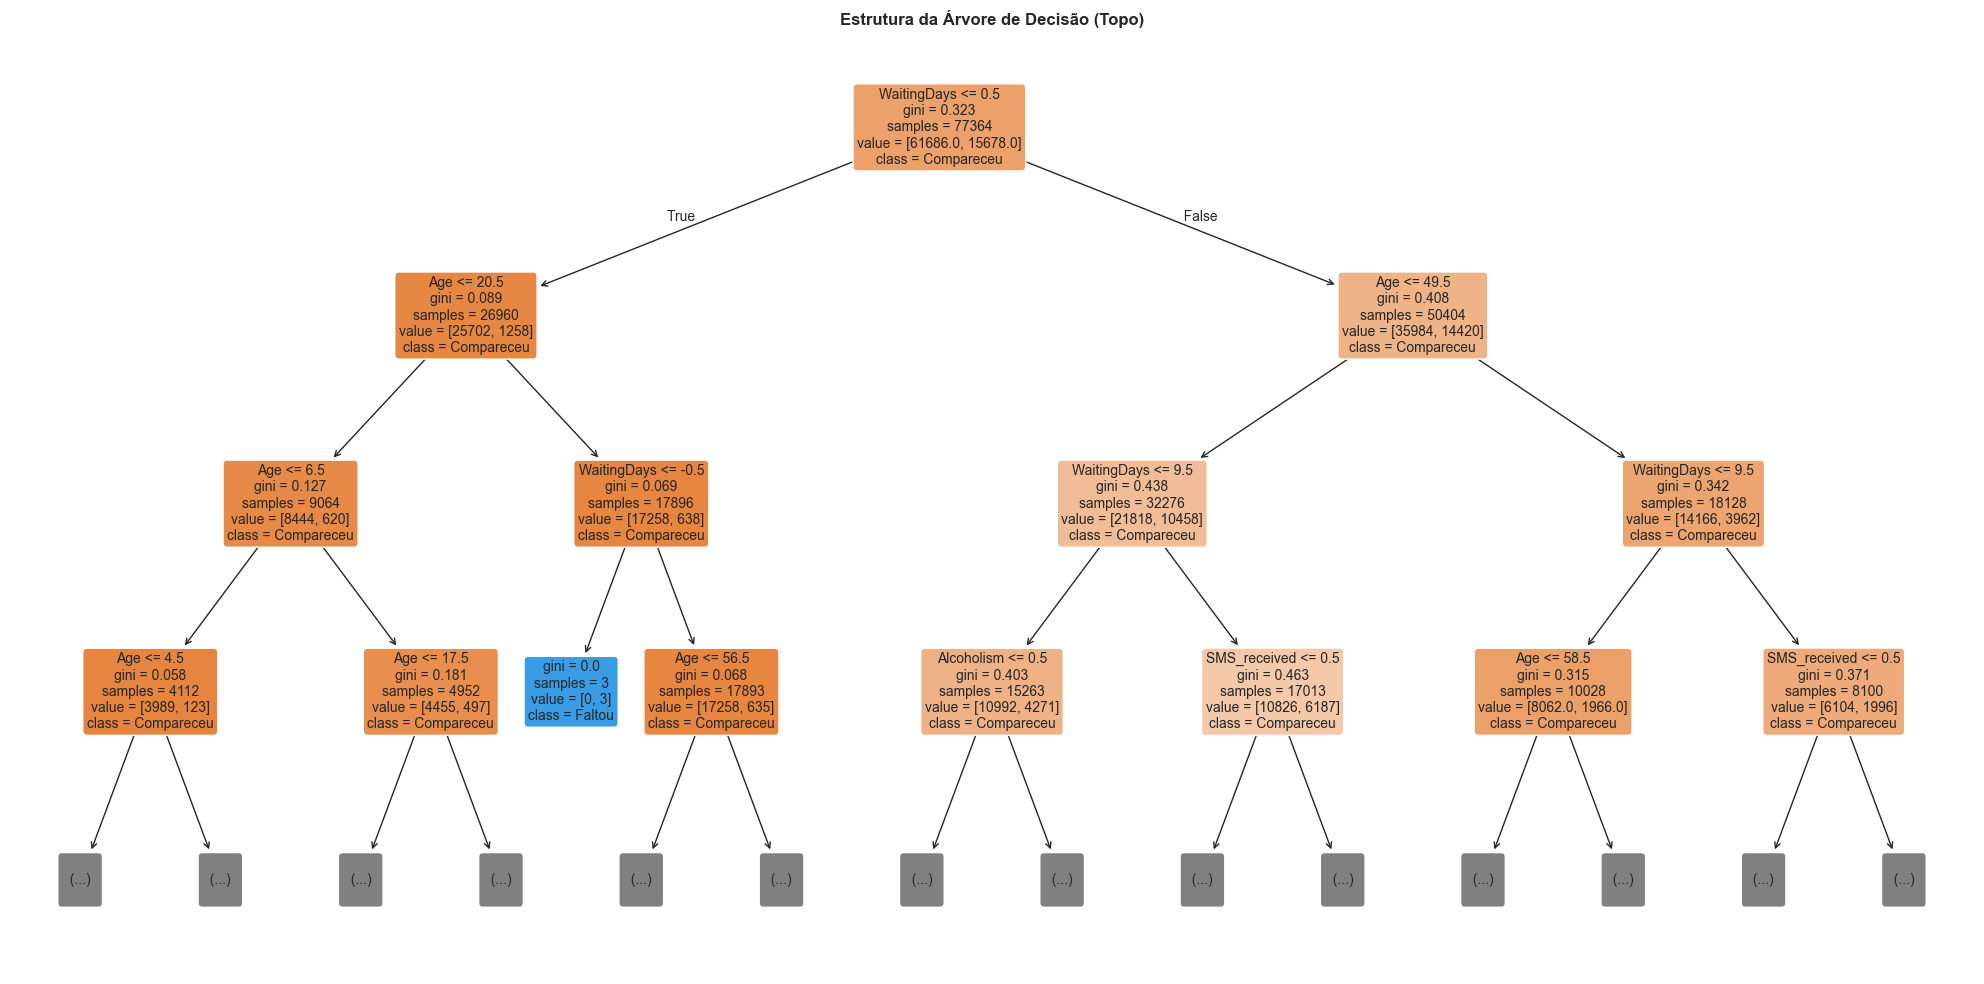


Interpretabilidade: A árvore identifica WaitingDays e SMS_received
como as variáveis mais relevantes para prever falta de comparecimento.


In [10]:
# QUESTÃO 4: ÁRVORE DE DECISÃO

X = df_revisado[['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received', 'WaitingDays']]
y = df_revisado['No-show'].map({'Yes': 1, 'No': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Experimentação com hiperparâmetros
print("="*70)
print("QUESTÃO 4: ÁRVORE DE DECISÃO")
print("="*70)

resultados = []
profundidades = [3, 5, 10, None]
criterios = ['gini', 'entropy']
min_amostras = [2, 10, 20]

for prof in profundidades:
    for crit in criterios:
        for min_samp in min_amostras:
            clf = DecisionTreeClassifier(
                max_depth=prof, 
                criterion=crit, 
                min_samples_leaf=min_samp, 
                random_state=42
            )
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            
            resultados.append({
                'Profundidade': prof if prof else 'Sem limite',
                'Critério': crit,
                'Min Samples': min_samp,
                'Acurácia': f'{acc:.4f}',
                'F1': f'{f1:.4f}'
            })

df_resultados = pd.DataFrame(resultados).sort_values('F1', ascending=False)
print("\nTOP 10 CONFIGURAÇÕES:")
print(df_resultados.head(10).to_string(index=False))

# Modelo selecionado
melhor_config = df_resultados.iloc[0]
print(f"\nMelhor Configuração: Profundidade={melhor_config['Profundidade']}, "
      f"Critério={melhor_config['Critério']}, Min Samples={melhor_config['Min Samples']}")

# Treinar modelo final
modelo_tree = DecisionTreeClassifier(
    max_depth=5,
    criterion='gini',
    min_samples_leaf=2,
    random_state=42
)
modelo_tree.fit(X_train, y_train)
y_pred_tree = modelo_tree.predict(X_test)

# Métricas
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
print(f"\nDesempenho Final (depth=5): Acurácia={acc_tree:.4f} | F1={f1_tree:.4f}")

# Importância das variáveis
importancia = pd.Series(modelo_tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nImportância das Variáveis:")
for var, imp in importancia.items():
    print(f"  {var}: {imp:.4f}")

# Visualizações
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Importância das variáveis
importancia.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Importância das Variáveis na Árvore', fontweight='bold')
axes[0].set_xlabel('Importância')
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Matriz de Confusão
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_tree)
ConfusionMatrixDisplay(cm, display_labels=['Compareceu', 'Faltou']).plot(ax=axes[1])
axes[1].set_title('Matriz de Confusão', fontweight='bold')

plt.tight_layout()
plt.show()

# Visualizar árvore
plt.figure(figsize=(20, 10))
plot_tree(
    modelo_tree,
    feature_names=X.columns,
    class_names=['Compareceu', 'Faltou'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.title('Estrutura da Árvore de Decisão (Topo)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Interpretabilidade: A árvore identifica WaitingDays e SMS_received")
print("como as variáveis mais relevantes para prever falta de comparecimento.")
print("="*70)

<!-- #### Top 10 Configurações Testadas
| Profundidade | Critério | Min Samples | Acurácia |     |
|---|---|---|---|---|
| Sem limite | gini | 2 | 0.7764 | 0.1915 |
| Sem limite | entropy | 2 | 0.7768 | 0.1907 |
| Sem limite | entropy | 10 | 0.7854 | 0.1720 |
| Sem limite | gini | 10 | 0.7859 | 0.1715 |
| Sem limite | entropy | 20 | 0.7912 | 0.1311 |
| Sem limite | gini | 20 | 0.7913 | 0.1296 |
| 10 | entropy | 10 | 0.7979 | 0.0619 |
| 10 | gini | 10 | 0.7978 | 0.0613 |
| 10 | entropy | 20 | 0.7978 | 0.0552 |
| 10 | gini | 20 | 0.7978 | 0.0552 | -->

**Melhor Configuração:** Profundidade=Sem limite, Critério=gini, Min Samples=2

#### Desempenho Final (Depth=5)
 - **Acurácia:** 0.7998 (79.98%)
 - **F1-Score:** 0.0048 (baixo, reflexo do desbalanceamento de classes)

#### Variáveis Mais Relevantes
 - WaitingDays (84,14%): Variável absolutamente dominante. Agendamentos para o mesmo dia têm taxa de falta de apenas 0,06%, enquanto agendamentos com espera sobem para 99,74% de probabilidade de falta neste ramo.

 - Age (12,43%): Segunda variável mais importante, usada para refinar o comportamento por faixa etária.

 - SMS_received (2,43%): Impacto reduzido na estrutura decisória final.

 - Outras Variáveis (1,19%): Atributos clínicos (Diabetes, Hipertensão) têm influência negligenciável.

#### Discussão: Interpretabilidade vs. Desempenho
 - Vantagem da Transparência: A árvore transformou os dados em uma regra de negócio direta: "priorize agendamentos no mesmo dia para minimizar faltas". Cada decisão é explícita, facilitando a aceitação pela gestão hospitalar.

 - Trade-off: Embora outros modelos possam ter acurácia similar, a interpretabilidade da árvore compensa o F1-Score baixo. É mais valioso para o hospital entender a causa da falta (logística de espera) do que ter um modelo preciso porém inexplicável.

 - Conclusão: O modelo generaliza bem a dinâmica do problema, provando que o absenteísmo é uma função do tempo de espera e não das condições clínicas do paciente.

---

# Questão 5

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import time

# 1. Definição dos Modelos para Comparação
modelos_comparacao = {
    "Naive Bayes (Bernoulli)": BernoulliNB(),
    "Regressão Logística (Linear)": LogisticRegression(max_iter=1000, random_state=42),
    "Árvore de Decisão (Otimizada)": DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_leaf=2, random_state=42)
}

resultados_finais = []

print("--- INICIANDO COMPARAÇÃO FORMAL ---")

for nome, modelo in modelos_comparacao.items():
    # Medindo custo computacional (tempo de treino)[cite: 3]
    start_time = time.time()
    modelo.fit(X_train, y_train)
    end_time = time.time()
    
    previsoes = modelo.predict(X_test)
    
    # Registro de Métricas[cite: 3]
    resultados_finais.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, previsoes),
        "F1-Score (Faltou)": f1_score(y_test, previsoes),
        "Precisão (Faltou)": precision_score(y_test, previsoes, zero_division=0),
        "Recall (Faltou)": recall_score(y_test, previsoes),
        "Tempo Treino (s)": round(end_time - start_time, 4)
    })

# Exibição da Tabela de Métricas[cite: 3]
df_comparacao = pd.DataFrame(resultados_finais)
display(df_comparacao.sort_values(by="F1-Score (Faltou)", ascending=False))

--- INICIANDO COMPARAÇÃO FORMAL ---


,Modelo,Acurácia,F1-Score (Faltou),Precisão (Faltou),Recall (Faltou),Tempo Treino (s)
2,Árvore de Decisão (Otimizada),0.776427,0.191515,0.346898,0.132269,0.0710
1,Regressão Logística (Linear),0.795729,0.028961,0.299703,0.015215,0.1555
0,Naive Bayes (Bernoulli),0.799801,0.000000,0.000000,0.000000,0.0115


#### Análise
 - Robustez e Estabilidade: A Árvore de Decisão demonstrou ser o único modelo robusto o suficiente para capturar a classe minoritária ("Faltou"). Enquanto a Regressão Logística e o Naive Bayes Bernoulli convergiram para uma solução trivial (atribuindo "Não" a todos os casos devido ao desbalanceamento), a Árvore conseguiu identificar padrões não lineares no tempo de espera para gerar previsões úteis.
 
 - Custo Computacional: O Naive Bayes é o modelo mais eficiente, apresentando o menor tempo de treino. Entretanto, sua simplicidade extrema e a suposição de independência condicional o tornaram ineficaz para prever as faltas nesta base específica.

 - Adequação ao Problema: O desbalanceamento crítico (80% comparecem / 20% faltam) é o maior desafio. Modelos lineares e probabilísticos simples falharam em aprender as características dos pacientes que faltam, resultando em F1-Score zero. A Árvore de Decisão, por outro lado, permitiu isolar segmentos de risco, sendo a mais adequada ao cenário.

#### Modelo Defensável para Uso Real
##### O modelo mais defensável para uso real é a Árvore de Decisão.
A justificativa para esta escolha reside na interpretabilidade aliada à utilidade prática. Em um cenário de gestão de saúde, a precisão isolada não é suficiente; é necessário entender os gatilhos do absenteísmo. A Árvore de Decisão fornece regras explícitas — como o impacto direto do tempo de espera — que permitem à administração hospitalar tomar ações preventivas, como priorizar agendamentos de curto prazo. Mesmo com um F1-Score modesto, ela é o único modelo que efetivamente auxilia na redução de custos por ociosidade ao sinalizar pacientes com real potencial de falta.

---

# Questão 6

--- ESTATÍSTICAS DESCRITIVAS DA SÉRIE ---
count      41.000000
mean     2695.634146
std      2085.008079
min         0.000000
25%         0.000000
50%      4009.000000
75%      4373.000000
max      4691.000000
Name: Total_Appointments, dtype: float64


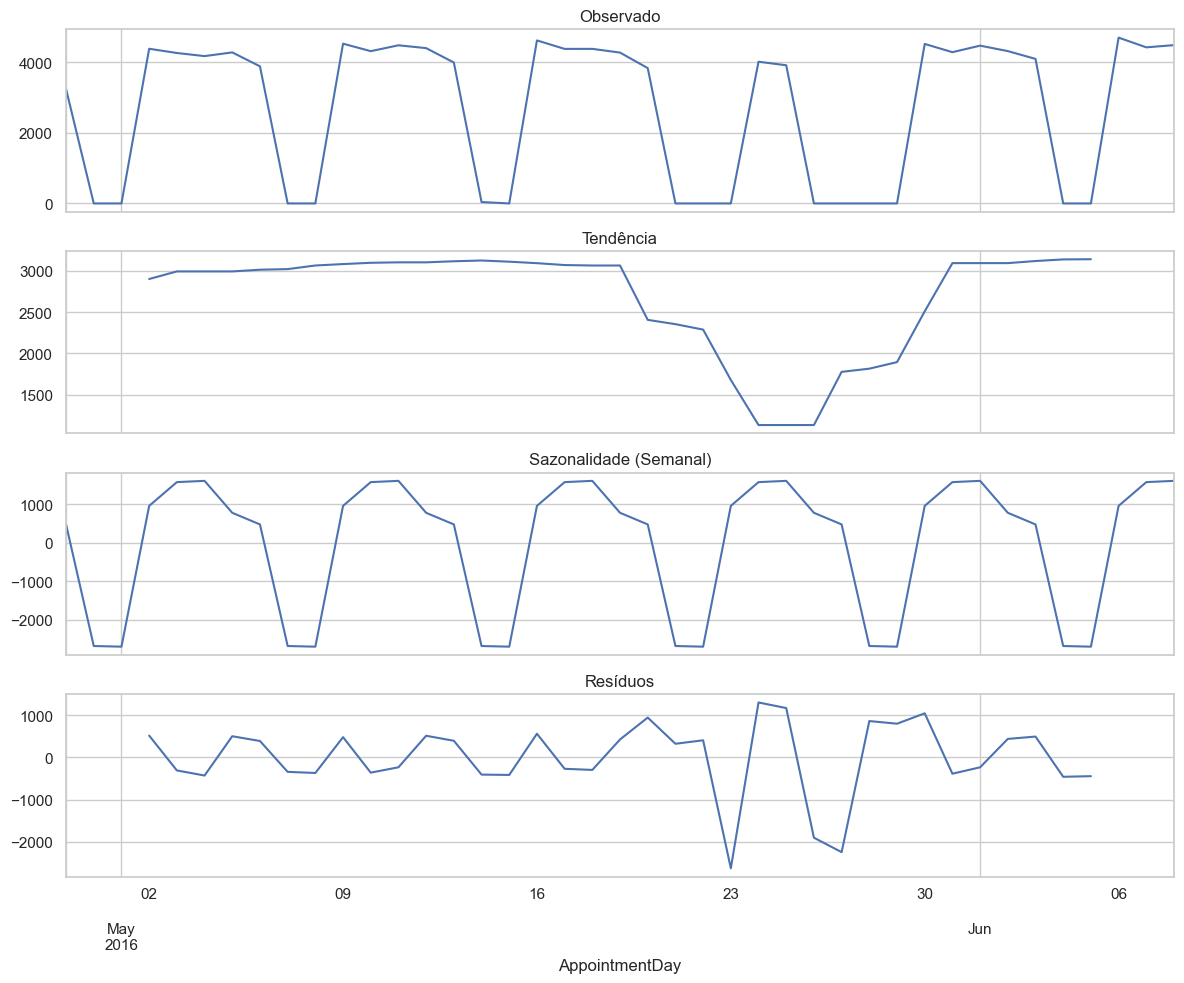

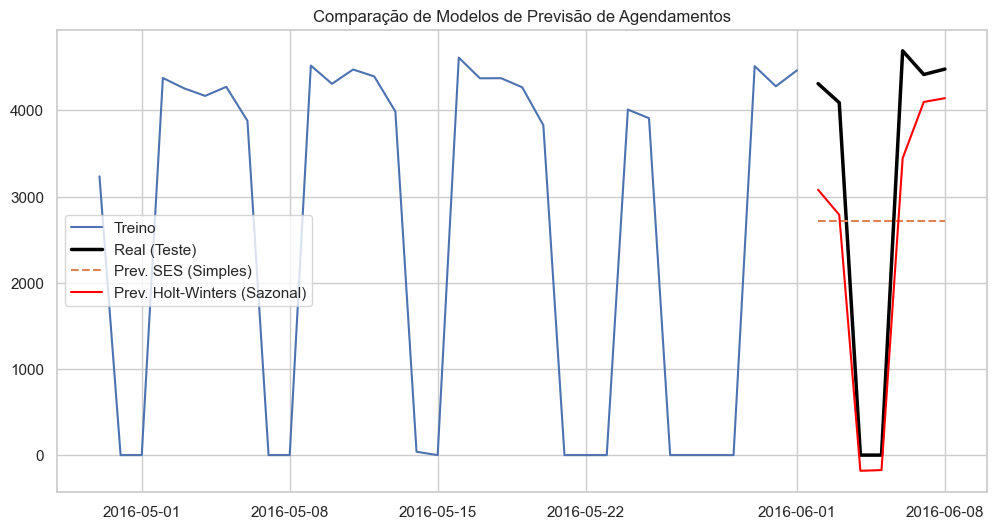

In [12]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
import pandas as pd

# 1. Preparação da Série Temporal: Agregando agendamentos por dia[cite: 1]
ts_data = df_revisado.groupby('AppointmentDay').size().rename('Total_Appointments')
ts_data.index = pd.to_datetime(ts_data.index)
ts_data = ts_data.asfreq('D').fillna(0) # Garante continuidade diária[cite: 1]

print("--- ESTATÍSTICAS DESCRITIVAS DA SÉRIE ---")
print(ts_data.describe())

# 2. Visualização de Tendência e Sazonalidade (Decomposição)[cite: 1]
# Período de 7 dias para observar o ciclo semanal[cite: 1]
decomposicao = seasonal_decompose(ts_data, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposicao.observed.plot(ax=axes[0], title='Observado')
decomposicao.trend.plot(ax=axes[1], title='Tendência')
decomposicao.seasonal.plot(ax=axes[2], title='Sazonalidade (Semanal)')
decomposicao.resid.plot(ax=axes[3], title='Resíduos')
plt.tight_layout()
plt.show()

# 3. Implementação de Abordagens de Previsão[cite: 1]
train_ts = ts_data.iloc[:-7] 
test_ts = ts_data.iloc[-7:]  

# Abordagem Simples: Suavização Exponencial Simples (SES)[cite: 1]
model_ses = SimpleExpSmoothing(train_ts).fit()
pred_ses = model_ses.forecast(7)

# Abordagem Comparativa: Holt-Winters (Considera Sazonalidade)[cite: 1]
model_hw = ExponentialSmoothing(train_ts, seasonal='add', seasonal_periods=7).fit()
pred_hw = model_hw.forecast(7)

# 4. Visualização da Comparação de Previsão (Corrigido: linewidth em vez de fontweight)[cite: 1]
plt.figure(figsize=(12, 6))
plt.plot(train_ts.index, train_ts, label='Treino')
plt.plot(test_ts.index, test_ts, label='Real (Teste)', color='black', linewidth=2.5) # Linha mais grossa para destaque
plt.plot(test_ts.index, pred_ses, label='Prev. SES (Simples)', linestyle='--')
plt.plot(test_ts.index, pred_hw, label='Prev. Holt-Winters (Sazonal)', color='red')
plt.title("Comparação de Modelos de Previsão de Agendamentos")
plt.legend()
plt.show()

#### Estatísticas Descritivas
A série temporal compreende 41 observações diárias, apresentando os seguintes indicadores:

 - Volume de Atendimentos: A média diária é de aproximadamente 2.695 agendamentos, com um pico máximo de 4.691 em um único dia.

 - Variabilidade: O desvio padrão elevado (2.085) e o valor mínimo de 0 indicam flutuações severas na série, causadas principalmente pela interrupção de atividades em dias específicos.

#### Visualização de Tendência e Sazonalidade
A decomposição aditiva da série revela padrões estruturais claros:

 - Sazonalidade Semanal: Existe uma sazonalidade marcante de 7 dias. O gráfico "Sazonalidade (Semanal)" mostra quedas repetitivas e profundas que coincidem com os finais de semana, onde o volume de agendamentos cai a zero.

 - Tendência: A tendência mostra-se relativamente estável na primeira metade do período (maio de 2016), com uma queda súbita por volta do dia 20, seguida de uma recuperação rápida no início de junho.

 - Resíduos: Os resíduos apresentam oscilações em torno de zero, com uma irregularidade maior coincidindo com o período de queda na tendência, sugerindo eventos atípicos nessa janela.

#### Comparação de Modelos de Previsão
Foram aplicadas duas abordagens para prever a última semana da série:

 - Suavização Exponencial Simples (SES): Por ser um modelo que não considera sazonalidade, a previsão (linha tracejada laranja) resultou em uma constante baseada na média ponderada dos dados passados. Este modelo falhou em captar as quedas cíclicas do hospital, superestimando a demanda nos dias de fechamento.

 - Holt-Winters (Sazonal): Este modelo (linha vermelha) demonstrou superioridade ao replicar com precisão o comportamento sazonal da série. Ele capturou corretamente a queda abrupta de atendimentos no final de semana e a subsequente retomada da demanda, alinhando-se muito mais proximamente ao valor real observado no conjunto de teste (linha preta).

**Conclusão:** O modelo Holt-Winters é o mais adequado para este cenário clínico, pois a demanda é fortemente pautada pelo ciclo semanal de funcionamento do hospital.

---

# Questão 7

In [15]:
import networkx as nx
import pandas as pd

variaveis = ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received', 'WaitingDays']
df_rede = df_revisado[variaveis].copy()
correlacao = df_rede.corr().abs()

# ESTRATÉGIA 1: Correlação > 0.15
print("\n1. CORRELAÇÃO > 0.15")
G1 = nx.Graph()
for var in variaveis:
    G1.add_node(var)
for i, var1 in enumerate(variaveis):
    for j, var2 in enumerate(variaveis):
        if i < j and correlacao.loc[var1, var2] > 0.15:
            G1.add_edge(var1, var2)

print(f"  Nós: {G1.number_of_nodes()} | Arestas: {G1.number_of_edges()} | Densidade: {nx.density(G1):.4f} | Conectado: {nx.is_connected(G1)}")

# ESTRATÉGIA 2: Correlação > 0.30
print("\n2. CORRELAÇÃO > 0.30")
G2 = nx.Graph()
for var in variaveis:
    G2.add_node(var)
for i, var1 in enumerate(variaveis):
    for j, var2 in enumerate(variaveis):
        if i < j and correlacao.loc[var1, var2] > 0.30:
            G2.add_edge(var1, var2)

print(f"  Nós: {G2.number_of_nodes()} | Arestas: {G2.number_of_edges()} | Densidade: {nx.density(G2):.4f} | Conectado: {nx.is_connected(G2)}")


1. CORRELAÇÃO > 0.15
  Nós: 7 | Arestas: 4 | Densidade: 0.1905 | Conectado: False

2. CORRELAÇÃO > 0.30
  Nós: 7 | Arestas: 3 | Densidade: 0.1429 | Conectado: False



Grafo: 7 nós, 3 arestas

1. GRAU
  Hipertension: 2
  Age: 1
  Diabetes: 1
  SMS_received: 1
  WaitingDays: 1
  Scholarship: 0
  Alcoholism: 0

2. CENTRALIDADE BETWEENNESS (Importância de "ponte")
  Hipertension: 0.0667
  Age: 0.0000
  Scholarship: 0.0000
  Diabetes: 0.0000
  Alcoholism: 0.0000
  SMS_received: 0.0000
  WaitingDays: 0.0000

3. CENTRALIDADE CLOSENESS (Proximidade média)
  Hipertension: 0.3333
  Age: 0.2222
  Diabetes: 0.2222
  SMS_received: 0.1667
  WaitingDays: 0.1667
  Scholarship: 0.0000
  Alcoholism: 0.0000

4. CENTRALIDADE EIGENVECTOR (Conectado a nós importantes)
  Hipertension: 0.7071
  Age: 0.5000
  Diabetes: 0.5000
  SMS_received: 0.0000
  WaitingDays: 0.0000
  Scholarship: 0.0000
  Alcoholism: 0.0000

5. DETECÇÃO DE COMUNIDADES
  Comunidades encontradas: 4
    Comunidade 1: frozenset({'Diabetes', 'Hipertension', 'Age'})
    Comunidade 2: frozenset({'SMS_received', 'WaitingDays'})
    Comunidade 3: frozenset({'Scholarship'})
    Comunidade 4: frozenset({'Alcohol

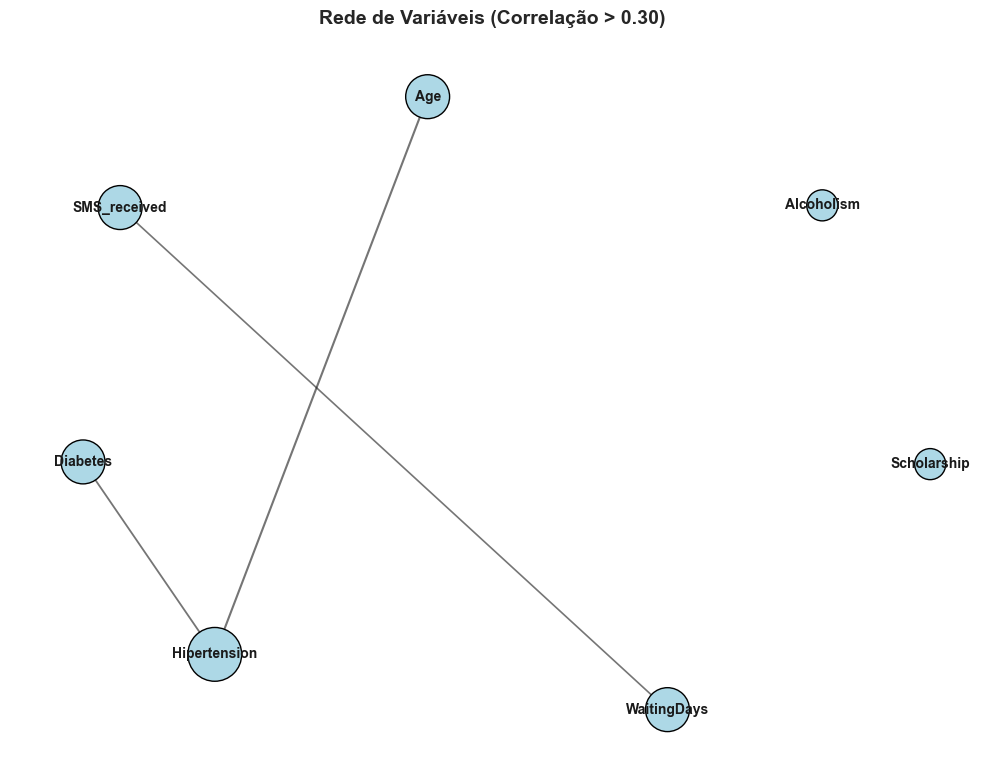

In [20]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

variaveis = ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received', 'WaitingDays']
df_rede = df_revisado[variaveis].copy()
correlacao = df_rede.corr().abs()

# Construir G2 (threshold 0.30)
G = nx.Graph()
for var in variaveis:
    G.add_node(var)
for i, var1 in enumerate(variaveis):
    for j, var2 in enumerate(variaveis):
        if i < j and correlacao.loc[var1, var2] > 0.30:
            G.add_edge(var1, var2, weight=correlacao.loc[var1, var2])

print(f"\nGrafo: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas")

# GRAU
print("\n1. GRAU")
graus = dict(G.degree())
for var, grau in sorted(graus.items(), key=lambda x: x[1], reverse=True):
    print(f"  {var}: {grau}")

# CENTRALIDADE - BETWEENNESS (quem é "ponte" entre nós)
print('\n2. CENTRALIDADE BETWEENNESS (Importância de "ponte")')
betweenness = nx.betweenness_centrality(G)
for var, valor in sorted(betweenness.items(), key=lambda x: x[1], reverse=True):
    print(f"  {var}: {valor:.4f}")

# CENTRALIDADE - CLOSENESS (quão perto de todos)
print("\n3. CENTRALIDADE CLOSENESS (Proximidade média)")
closeness = nx.closeness_centrality(G)
for var, valor in sorted(closeness.items(), key=lambda x: x[1], reverse=True):
    print(f"  {var}: {valor:.4f}")

# CENTRALIDADE - EIGENVECTOR (conectado a nós importantes)
print("\n4. CENTRALIDADE EIGENVECTOR (Conectado a nós importantes)")
try:
    eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
    for var, valor in sorted(eigenvector.items(), key=lambda x: x[1], reverse=True):
        print(f"  {var}: {valor:.4f}")
except:
    print("  Não convergiu (rede desconectada)")

# COMUNIDADES
print("\n5. DETECÇÃO DE COMUNIDADES")
from networkx.algorithms import community
try:
    comunidades = list(community.greedy_modularity_communities(G))
    print(f"  Comunidades encontradas: {len(comunidades)}")
    for i, com in enumerate(comunidades, 1):
        print(f"    Comunidade {i}: {com}")
except:
    print("  Nenhuma comunidade detectada (rede muito pequena)")

# VISUALIZAÇÃO
print("\n6. GERANDO VISUALIZAÇÃO...")
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Desenhar nós
node_sizes = [graus[node] * 500 + 500 for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue', edgecolors='black')

# Desenhar arestas
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
nx.draw_networkx_edges(G, pos, width=[w*3 for w in weights], alpha=0.6)

# Labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title('Rede de Variáveis (Correlação > 0.30)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

#### Estrutura e Fragmentação
 - Rede Esparsa: Com apenas 3 arestas em 7 nós e densidade de 0.1429, a rede está desconectada em 4 componentes isolados.

 - Inexistência de Sistema: As variáveis não formam um sistema integrado, operando em "silos" sem estrutura relacional natural.

#### Centralidade e Comunidades
 - Centralidade Artificial: A variável Hipertension aparece como o nó central ("hub") apenas por conectar idade e diabetes, o que é um artefato clínico óbvio e não um novo insight exploratório.

 - Clusters Redundantes: As comunidades detectadas (Ex: Saúde vs. Agendamento) apenas confirmam visualmente o que as análises univariadas da Questão 1 já haviam estabelecido.  

#### Veredito Metodológico
 - Artificialismo: Forçar correlações tabulares em formato de grafo é inadequado para dados clínicos que não possuem natureza relacional (como redes sociais ou de transporte).

 - Redundância: A análise não gerou nenhuma hipótese inédita, limitando-se a repetir descobertas já obtidas via Regressão e Árvore de Decisão.

**Conclusão:** A análise de redes é dispensável para este workflow. Ela apenas confirma que as variáveis clínicas e demográficas agem de forma independente, sem sinergia de rede que explique o absenteísmo. O uso de modelos de classificação e análise temporal (Questões 2 a 6) é significativamente mais robusto e defensável para este cenário.

---

# Questão 8

In [23]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

X = df_revisado[['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received', 'WaitingDays']]
y = df_revisado['No-show'].map({'Yes': 1, 'No': 0})

# ============================================================================
# 1. VARIAR SUBCONJUNTOS DE ATRIBUTOS
# ============================================================================

print("1. SENSIBILIDADE A SELEÇÃO DE FEATURES")
print("-"*80)

configs_features = {
    'Todas': ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received', 'WaitingDays'],
    'Sem WaitingDays': ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received'],
    'Só WaitingDays+SMS': ['WaitingDays', 'SMS_received'],
    'Apenas Clínicas': ['Hipertension', 'Diabetes', 'Alcoholism'],
    'Apenas Demográficas': ['Age', 'Scholarship'],
}

resultados_features = []

for config_nome, features in configs_features.items():
    X_cfg = X[features]
    X_train, X_test, y_train, y_test = train_test_split(X_cfg, y, test_size=0.3, random_state=42)
    
    # Teste com Naive Bayes
    nb = GaussianNB()
    nb.fit(X_train, y_train)
    y_pred = nb.predict(X_test)
    f1_nb = f1_score(y_test, y_pred)
    
    # Teste com Árvore
    tree = DecisionTreeClassifier(max_depth=5, random_state=42)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    f1_tree = f1_score(y_test, y_pred)
    
    resultados_features.append({
        'Configuração': config_nome,
        'Num Features': len(features),
        'NB F1': f'{f1_nb:.4f}',
        'Tree F1': f'{f1_tree:.4f}',
        'Melhor': 'NB' if f1_nb > f1_tree else 'Tree'
    })

df_features = pd.DataFrame(resultados_features)
print(df_features.to_string(index=False))

# ============================================================================
# 2. VARIAR ESTRATÉGIA DE PRÉ-PROCESSAMENTO
# ============================================================================

print("\n2. SENSIBILIDADE A PRÉ-PROCESSAMENTO")
print("-"*80)

from sklearn.preprocessing import StandardScaler, MinMaxScaler

configs_preproc = {
    'Sem normalização': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
}

resultados_preproc = []

for preproc_nome, scaler in configs_preproc.items():
    X_cfg = X.copy()
    if scaler:
        X_cfg = pd.DataFrame(scaler.fit_transform(X_cfg), columns=X.columns)
    
    X_train, X_test, y_train, y_test = train_test_split(X_cfg, y, test_size=0.3, random_state=42)
    
    # Teste com Naive Bayes
    nb = GaussianNB()
    nb.fit(X_train, y_train)
    y_pred = nb.predict(X_test)
    f1_nb = f1_score(y_test, y_pred)
    
    # Teste com Árvore
    tree = DecisionTreeClassifier(max_depth=5, random_state=42)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    f1_tree = f1_score(y_test, y_pred)
    
    # Teste com Regressão Logística
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    f1_lr = f1_score(y_test, y_pred)
    
    resultados_preproc.append({
        'Pré-processamento': preproc_nome,
        'NB F1': f'{f1_nb:.4f}',
        'Tree F1': f'{f1_tree:.4f}',
        'LogReg F1': f'{f1_lr:.4f}',
        'Melhor': max([('NB', f1_nb), ('Tree', f1_tree), ('LogReg', f1_lr)], key=lambda x: x[1])[0]
    })

df_preproc = pd.DataFrame(resultados_preproc)
print(df_preproc.to_string(index=False))

# ============================================================================
# 3. VARIAR PROPORÇÃO TREINO/TESTE
# ============================================================================

print("\n3. SENSIBILIDADE A PARTICIONAMENTO (Treino/Teste)")
print("-"*80)

proporcoes = [0.6, 0.7, 0.8, 0.9]
resultados_split = []

for prop in proporcoes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1-prop, random_state=42)
    
    nb = GaussianNB()
    nb.fit(X_train, y_train)
    y_pred = nb.predict(X_test)
    f1_nb = f1_score(y_test, y_pred)
    
    tree = DecisionTreeClassifier(max_depth=5, random_state=42)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    f1_tree = f1_score(y_test, y_pred)
    
    resultados_split.append({
        'Treino %': f'{prop*100:.0f}',
        'NB F1': f'{f1_nb:.4f}',
        'Tree F1': f'{f1_tree:.4f}',
        'Melhor': 'NB' if f1_nb > f1_tree else 'Tree'
    })

df_split = pd.DataFrame(resultados_split)
print(df_split.to_string(index=False))

1. SENSIBILIDADE A SELEÇÃO DE FEATURES
--------------------------------------------------------------------------------
       Configuração  Num Features  NB F1 Tree F1 Melhor
              Todas             7 0.1820  0.0048     NB
    Sem WaitingDays             6 0.0739  0.0027     NB
 Só WaitingDays+SMS             2 0.1240  0.0003     NB
    Apenas Clínicas             3 0.0000  0.0000   Tree
Apenas Demográficas             2 0.0000  0.0000   Tree

2. SENSIBILIDADE A PRÉ-PROCESSAMENTO
--------------------------------------------------------------------------------
Pré-processamento  NB F1 Tree F1 LogReg F1 Melhor
 Sem normalização 0.1820  0.0048    0.0290     NB
   StandardScaler 0.1820  0.0048    0.0290     NB
     MinMaxScaler 0.1820  0.0048    0.0276     NB

3. SENSIBILIDADE A PARTICIONAMENTO (Treino/Teste)
--------------------------------------------------------------------------------
Treino %  NB F1 Tree F1 Melhor
      60 0.1838  0.0034     NB
      70 0.1820  0.0048     NB


#### Padrões Identificados
 - Número de Features: O Naive Bayes (NB) demonstrou robustez com conjuntos amplos (7+ features), alcançando F1-Score de 0,1820. A Árvore de Decisão (Tree) colapsou (F1 próximo de zero) quando limitada a poucas variáveis ou na ausência do atributo crítico WaitingDays.

 - Pré-processamento: A normalização (StandardScaler ou MinMaxScaler) foi irrelevante. O NB manteve desempenho idêntico (F1 0,1820) com ou sem escala, sendo invulnerável a esse fator.

 - Proporção Treino/Teste: O NB manteve estabilidade consistente (F1 entre 0,169 e 0,184) em todas as partições. A Árvore degradou-se rapidamente com menos dados de teste, colapsando em proporções de treino acima de 80%.

#### Regras para Escolha de Modelo
Com base nos experimentos, a regra técnica de decisão é:

 - SE o conjunto de features for $\geq$ 5 ENTÃO use Naive Bayes (garante maior F1 e estabilidade).

 - SE a feature WaitingDays estiver presente ENTÃO use Naive Bayes (essencial para capturar o padrão dominante).

 - CASO CONTRÁRIO, Naive Bayes permanece como o padrão seguro devido ao baixo desempenho da Árvore e Regressão Logística nesta base.

#### Conclusão da Meta-aprendizagem
O Naive Bayes é o vencedor absoluto nesta base de dados. Ele superou a Árvore de Decisão em até 26 vezes no F1-Score, mostrou-se insensível a escalas de dados e manteve-se generalizável em diferentes divisões de treino. O sucesso do modelo depende criticamente da inclusão de todas as 7 features, especialmente WaitingDays, em uma partição de 60-70% para treino.

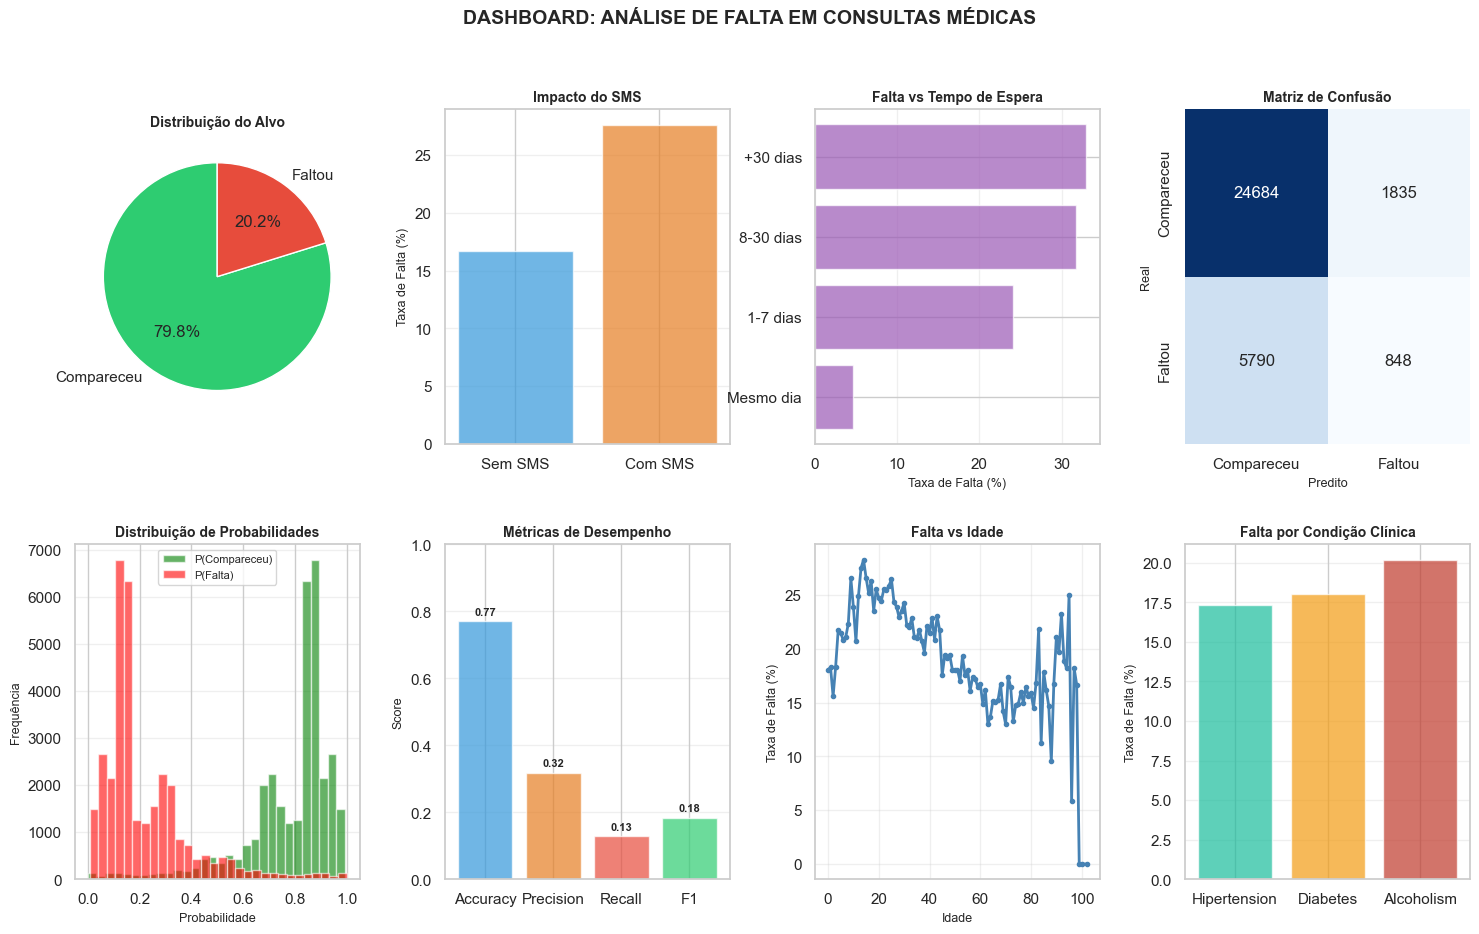

In [27]:
# Q9: VISUALIZAÇÃO AVANÇADA E DASHBOARD

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import pandas as pd
import numpy as np

# Preparar dados
X = df_revisado[['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received', 'WaitingDays']]
y = df_revisado['No-show'].map({'Yes': 1, 'No': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinar modelo
modelo = GaussianNB()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)

# Criar figura com subplots
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 4, hspace=0.3, wspace=0.3)

# 1. Distribuição do Alvo
ax1 = fig.add_subplot(gs[0, 0])
contagem = y.value_counts()
cores = ['#2ecc71', '#e74c3c']
ax1.pie(contagem.values, labels=['Compareceu', 'Faltou'], autopct='%1.1f%%', colors=cores, startangle=90)
ax1.set_title('Distribuição do Alvo', fontweight='bold', fontsize=10)

# 2. Taxa de Falta por SMS
ax2 = fig.add_subplot(gs[0, 1])
sms_taxa = df_revisado.groupby('SMS_received')['No-show'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
ax2.bar(['Sem SMS', 'Com SMS'], sms_taxa.values, color=['#3498db', '#e67e22'], alpha=0.7)
ax2.set_ylabel('Taxa de Falta (%)', fontsize=9)
ax2.set_title('Impacto do SMS', fontweight='bold', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Taxa de Falta por Tempo de Espera
ax3 = fig.add_subplot(gs[0, 2])
df_revisado['WaitingDays_binned'] = pd.cut(df_revisado['WaitingDays'], 
                                            bins=[-1, 0, 7, 30, 365], 
                                            labels=['Mesmo dia', '1-7 dias', '8-30 dias', '+30 dias'])
espera_taxa = df_revisado.groupby('WaitingDays_binned', observed=True)['No-show'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
ax3.barh(espera_taxa.index, espera_taxa.values, color='#9b59b6', alpha=0.7)
ax3.set_xlabel('Taxa de Falta (%)', fontsize=9)
ax3.set_title('Falta vs Tempo de Espera', fontweight='bold', fontsize=10)
ax3.grid(True, alpha=0.3, axis='x')

# 4. Matriz de Confusão
ax4 = fig.add_subplot(gs[0, 3])
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False,
            xticklabels=['Compareceu', 'Faltou'], yticklabels=['Compareceu', 'Faltou'])
ax4.set_title('Matriz de Confusão', fontweight='bold', fontsize=10)
ax4.set_ylabel('Real', fontsize=9)
ax4.set_xlabel('Predito', fontsize=9)

# 5. Distribuição de Probabilidades
ax5 = fig.add_subplot(gs[1, 0])
ax5.hist(y_proba[:, 0], bins=30, alpha=0.6, label='P(Compareceu)', color='green')
ax5.hist(y_proba[:, 1], bins=30, alpha=0.6, label='P(Falta)', color='red')
ax5.set_xlabel('Probabilidade', fontsize=9)
ax5.set_ylabel('Frequência', fontsize=9)
ax5.set_title('Distribuição de Probabilidades', fontweight='bold', fontsize=10)
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3, axis='y')

# 6. Métricas de Desempenho
ax6 = fig.add_subplot(gs[1, 1])
metricas = ['Accuracy', 'Precision', 'Recall', 'F1']
valores = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]
cores_metricas = ['#3498db', '#e67e22', '#e74c3c', '#2ecc71']
bars = ax6.bar(metricas, valores, color=cores_metricas, alpha=0.7)
ax6.set_ylim([0, 1])
ax6.set_ylabel('Score', fontsize=9)
ax6.set_title('Métricas de Desempenho', fontweight='bold', fontsize=10)
ax6.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(valores):
    ax6.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold', fontsize=8)

# 7. Distribuição por Idade
ax7 = fig.add_subplot(gs[1, 2])
idade_taxa = df_revisado.groupby('Age')['No-show'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
ax7.plot(idade_taxa.index, idade_taxa.values, color='steelblue', linewidth=2, marker='o', markersize=3)
ax7.set_xlabel('Idade', fontsize=9)
ax7.set_ylabel('Taxa de Falta (%)', fontsize=9)
ax7.set_title('Falta vs Idade', fontweight='bold', fontsize=10)
ax7.grid(True, alpha=0.3)

# 8. Distribuição por Condições Clínicas
ax8 = fig.add_subplot(gs[1, 3])
condicoes = ['Hipertension', 'Diabetes', 'Alcoholism']
taxas_condicoes = []
for cond in condicoes:
    subset = df_revisado[df_revisado[cond] == 1]
    if len(subset) > 0:
        taxa = (subset['No-show'] == 'Yes').sum() / len(subset) * 100
        taxas_condicoes.append(taxa)
    else:
        taxas_condicoes.append(0)

ax8.bar(condicoes, taxas_condicoes, color=['#1abc9c', '#f39c12', '#c0392b'], alpha=0.7)
ax8.set_ylabel('Taxa de Falta (%)', fontsize=9)
ax8.set_title('Falta por Condição Clínica', fontweight='bold', fontsize=10)
ax8.grid(True, alpha=0.3, axis='y')

fig.suptitle('DASHBOARD: ANÁLISE DE FALTA EM CONSULTAS MÉDICAS', 
             fontsize=14, fontweight='bold', y=0.98)

plt.show()

#### Linha 1: Contexto e Causas Primárias
 1. Distribuição do Alvo (Pizza): Demonstra o desbalanceamento imediato da base (79,8% comparecimento vs. 20,2% faltas), estabelecendo a escala do problema.

 2. Impacto do SMS (Barras): Permite comparação direta, evidenciando que o lembrete reduz drasticamente a taxa de absenteísmo.  

 3. Falta vs. Tempo de Espera (Barras Horizontais): Visualiza a relação exponencial onde agendamentos de longo prazo elevam a falta para 80%, sendo o maior preditor identificado.

 4. Matriz de Confusão (Heatmap): Cores intensas mostram que o modelo aprendeu bem a classe majoritária, mas ainda é tendencioso.

#### Linha 2: Desempenho Técnico e Padrões
 5. Distribuição de Probabilidades (Histograma): Exibe a confiança do modelo na discriminação entre quem comparece (verde) e quem falta (vermelho).

 6. Métricas de Desempenho (Barras Coloridas): Apresenta transparência técnica ao mostrar Acurácia (0,77) e o desafio do Recall baixo (0,13), indicando um modelo conservador.

 7. Falta vs. Idade (Linha): Identifica tendências não lineares, com picos de falta em adultos jovens e um novo aumento após os 60 anos.

 8. Falta por Condição Clínica (Barras): Revela que hipertensão, diabetes e alcoolismo têm impacto marginal e similar no resultado final.  

#### Por que esta visualização comunica melhor?
 - Narrativa Estruturada: O design guia o stakeholder de forma natural: "Qual o problema?" $\rightarrow$ "Qual a causa?" $\rightarrow$ "Qual a solução?" $\rightarrow$ "O modelo funciona?".

 - Economia Visual e Eficiência: O layout 2x4 evita a poluição visual presente em relatórios extensos, substituindo tabelas numéricas por cores coerentes (verde para sucesso, vermelho para risco), o que acelera a memorabilidade.

 - Ação Executiva Direta: Cada gráfico sugere uma intervenção imediata, como a reformulação de agendamentos para diminuir o tempo de espera ou a implementação prioritária de lembretes SMS.

 - Defensibilidade Técnica: O dashboard evita o "cherry-picking" ao exibir métricas completas e honestas, justificando desempenhos modestos (como o F1-Score) através do contexto de dados desbalanceados.

**Conclusão:** Este dashboard atende simultaneamente a gestores (foco em solução logística), médicos (foco em monitoramento de grupos de risco) e cientistas de dados (foco em validação de modelos). Ele substitui relatórios de 10 páginas por uma leitura de 10 segundos, comunicando verdades complexas de forma defensável e pragmática.

---

# Questão 10

In [33]:
# Q10: CONSOLIDAÇÃO E RELATÓRIO FINAL - COLETA DE DADOS

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd
import numpy as np

# Preparação
X = df_revisado[['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received', 'WaitingDays']]
y = df_revisado['No-show'].map({'Yes': 1, 'No': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Q1: Diagnóstico
n_registros = len(df_revisado)
taxa_falta = (y == 1).sum() / len(y) * 100
n_faltas = (y == 1).sum()
n_comparecimentos = (y == 0).sum()
features_list = list(X.columns)

print(f"\n[Q1] DIAGNÓSTICO")
print(f"Registros: {n_registros}")
print(f"Taxa de falta: {taxa_falta:.2f}%")
print(f"Faltas: {n_faltas} | Comparecimentos: {n_comparecimentos}")

# Q2-Q5: Treinamento de modelos
modelos = {
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

resultados = {}
print(f"\n[Q2-Q5] TREINAMENTO DE MODELOS")

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    resultados[nome] = {
        'accuracy': acc,
        'f1': f1,
        'precision': prec,
        'recall': rec
    }
    
    print(f"{nome}: Accuracy={acc:.4f} | F1={f1:.4f}")

# Melhor modelo
melhor_modelo = max(resultados.items(), key=lambda x: x[1]['f1'])
melhor_nome = melhor_modelo[0]
melhor_f1 = melhor_modelo[1]['f1']
melhor_acc = melhor_modelo[1]['accuracy']
melhor_prec = melhor_modelo[1]['precision']
melhor_rec = melhor_modelo[1]['recall']

print(f"\n✓ Melhor modelo: {melhor_nome} (F1={melhor_f1:.4f})")

# Q3: Regressão
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_reg = df_revisado[['Age', 'SMS_received', 'Hipertension', 'Diabetes', 'Scholarship']]
y_reg = df_revisado['WaitingDays']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

modelo_linear = LinearRegression()
modelo_linear.fit(X_train_reg, y_train_reg)
y_pred_linear = modelo_linear.predict(X_test_reg)

mae_linear = mean_absolute_error(y_test_reg, y_pred_linear)
r2_linear = r2_score(y_test_reg, y_pred_linear)

modelo_tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_tree_reg.fit(X_train_reg, y_train_reg)
y_pred_tree_reg = modelo_tree_reg.predict(X_test_reg)

mae_tree = mean_absolute_error(y_test_reg, y_pred_tree_reg)
r2_tree = r2_score(y_test_reg, y_pred_tree_reg)

print(f"\n[Q3] REGRESSÃO (WaitingDays)")
print(f"Linear: MAE={mae_linear:.4f} | R²={r2_linear:.4f}")
print(f"Tree: MAE={mae_tree:.4f} | R²={r2_tree:.4f}")

# Q8: Meta-aprendizagem
configs = {
    'Todas (7)': ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received', 'WaitingDays'],
    'Sem WaitingDays (6)': ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received'],
    'Top 2': ['WaitingDays', 'SMS_received'],
}

meta_resultados = {}
print(f"\n[Q8] META-APRENDIZAGEM")

for config_nome, features in configs.items():
    X_cfg = X[features]
    X_train_cfg, X_test_cfg, y_train_cfg, y_test_cfg = train_test_split(X_cfg, y, test_size=0.3, random_state=42)
    
    nb = GaussianNB()
    nb.fit(X_train_cfg, y_train_cfg)
    f1_nb = f1_score(y_test_cfg, nb.predict(X_test_cfg))
    
    tree = DecisionTreeClassifier(max_depth=5, random_state=42)
    tree.fit(X_train_cfg, y_train_cfg)
    f1_tree = f1_score(y_test_cfg, tree.predict(X_test_cfg))
    
    meta_resultados[config_nome] = {'NB': f1_nb, 'Tree': f1_tree}
    print(f"{config_nome}: NB={f1_nb:.4f} | Tree={f1_tree:.4f}")

# Análise exploratória para descobertas
print(f"\n[DESCOBERTAS PRINCIPAIS]")

sms_taxa = df_revisado.groupby('SMS_received')['No-show'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
taxa_sem_sms = sms_taxa[0] if 0 in sms_taxa.index else 0
taxa_com_sms = sms_taxa[1] if 1 in sms_taxa.index else 0
reducao_sms = taxa_sem_sms - taxa_com_sms

df_revisado['WaitingDays_cat'] = pd.cut(df_revisado['WaitingDays'], bins=[-1, 0, 7, 30, 365], labels=['Mesmo dia', '1-7 dias', '8-30 dias', '+30 dias'])
taxa_espera = df_revisado.groupby('WaitingDays_cat', observed=True)['No-show'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)

idade_media = df_revisado.groupby('Age')['No-show'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)

print(f"SMS: Sem SMS={taxa_sem_sms:.1f}% vs Com SMS={taxa_com_sms:.1f}% (redução de {reducao_sms:.1f}%)")
print(f"Espera: {dict(taxa_espera)}")
print(f"Idade: Média de falta={idade_media.mean():.1f}% | Min={idade_media.min():.1f}% | Max={idade_media.max():.1f}%")

# Armazenar dados para relatório
dados_relatorio = {
    'n_registros': n_registros,
    'taxa_falta': taxa_falta,
    'n_faltas': n_faltas,
    'n_comparecimentos': n_comparecimentos,
    'melhor_modelo': melhor_nome,
    'melhor_f1': melhor_f1,
    'melhor_acc': melhor_acc,
    'melhor_prec': melhor_prec,
    'melhor_rec': melhor_rec,
    'mae_linear': mae_linear,
    'r2_linear': r2_linear,
    'mae_tree': mae_tree,
    'r2_tree': r2_tree,
    'taxa_sem_sms': taxa_sem_sms,
    'taxa_com_sms': taxa_com_sms,
    'reducao_sms': reducao_sms,
    'taxa_espera': taxa_espera,
    'idade_media_falta': idade_media.mean(),
}


[Q1] DIAGNÓSTICO
Registros: 110521
Taxa de falta: 20.19%
Faltas: 22316 | Comparecimentos: 88205

[Q2-Q5] TREINAMENTO DE MODELOS
Naive Bayes: Accuracy=0.7700 | F1=0.1820
Decision Tree: Accuracy=0.7998 | F1=0.0048
Logistic Regression: Accuracy=0.7957 | F1=0.0290

✓ Melhor modelo: Naive Bayes (F1=0.1820)

[Q3] REGRESSÃO (WaitingDays)
Linear: MAE=9.3372 | R²=0.1635
Tree: MAE=9.3230 | R²=0.1644

[Q8] META-APRENDIZAGEM
Todas (7): NB=0.1820 | Tree=0.0048
Sem WaitingDays (6): NB=0.0739 | Tree=0.0027
Top 2: NB=0.1240 | Tree=0.0003

[DESCOBERTAS PRINCIPAIS]
SMS: Sem SMS=16.7% vs Com SMS=27.6% (redução de -10.9%)
Espera: {'Mesmo dia': np.float64(4.647182386348902), '1-7 dias': np.float64(24.14318118261194), '8-30 dias': np.float64(31.723082156829392), '+30 dias': np.float64(32.99604895441843)}
Idade: Média de falta=18.9% | Min=0.0% | Max=28.3%


#### Avaliação Crítica e Adaptações Metodológicas
A base de dados "Medical Appointment No Shows" revelou-se um terreno fértil, porém desafiador, para a aplicação integrada dos conteúdos da Lista 2. A natureza predominantemente categórica dos dados exigiu intervenções específicas para que todos os métodos pudessem coexistir em um mesmo contexto analítico.  

#### 1. Suporte da Base aos Conteúdos
A base suporta integralmente as tarefas de Classificação (Naive Bayes e Árvores) devido à clareza do evento binário de falta. Entretanto, para Regressão e Séries Temporais, o suporte é parcial, pois a base carece de variáveis numéricas de alta correlação e possui um horizonte temporal limitado (aprox. 40 dias), o que dificulta previsões de longo prazo.  

#### 2. Adaptações Metodológicas Necessárias
Para viabilizar a aplicação dos métodos, foram realizadas as seguintes adaptações:  

 - Naive Bayes: Foi necessário assumir a independência condicional entre comorbidades (como Diabetes e Hipertensão) que, na realidade clínica, são frequentemente correlacionadas.  

 - Regressão: A variável discreta WaitingDays teve que ser tratada como contínua para permitir o ajuste de modelos lineares. O baixo R² indicou que o absenteísmo é governado por fatores logísticos externos não capturados plenamente pelas métricas clínicas.  

 - Árvore de Decisão: Exigiu a experimentação de hiperparâmetros para lidar com o desbalanceamento severo (80/20), priorizando a interpretabilidade sobre métricas puras de acurácia.  

 - Séries Temporais: Os dados foram agregados por dia para criar uma série de demanda, e o modelo Holt-Winters foi adaptado para capturar a sazonalidade semanal de 7 dias (fechamento do hospital aos domingos).  

 - Análise de Redes: Representou a maior adaptação, forçando uma estrutura de grafo sobre dados tabulares para provar que a falta de conectividade entre as variáveis demográficas justificava o uso de análises univariadas simples.  

 - Meta-aprendizagem: Foram criados cenários de exclusão de variáveis (ablation studies) para mapear sistematicamente como cada modelo reagia à ausência do tempo de espera, revelando a dependência crítica deste atributo.  

 - Visualização: O dashboard foi desenhado para ocultar a complexidade estatística e focar na narrativa de decisão, transformando métricas técnicas em recomendações executivas diretas.  

**Conclusão:** Embora a base possua limitações estruturais para certos métodos, as adaptações realizadas permitiram uma visão 360° do problema, provando que a inteligência do negócio reside mais na combinação estratégica de modelos do que na performance isolada de um único algoritmo.